In [1]:
#%pip install --upgrade omfit_classes

In [2]:
#%pip install omas

In [3]:
from omfit_classes import omfit_eqdsk

In [4]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from uncertainties import ufloat
import numpy as np
from scipy.integrate import cumulative_trapezoid
from scipy.constants import mu_0
import os

In [5]:
#volume average
def vol_avg(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN'] 
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        prof_sized_vol_avg = prof_sized_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_sized_vol_avg
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        prof_vol_avg = prof_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_vol_avg

#H factor definitions
def vol_integral(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN']
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        return prof_sized_vol_int
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        return prof_vol_int

def taue_h_mode(x,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58): #M = 2.5 for DT
    h_mode_vars = [x['ip'],x['bcentr'],x['density'],x['ptot_cps'],x['rsurf'],x['kappa'],x['eps']]
    return 0.0562*2.5**(0.19)*np.prod(np.power(h_mode_vars,np.array([a1,a2,a3,a4,a5,a6,a7])))

def taue_l_mode(x,a1=0.85,a2=1.2,a3=0.3,a4=0.5,a5=0.1,a6=0.2,a7=-0.5): #M = 2.5 for DT
    l_mode_vars = [x['ip'],x['rsurf'],x['aminor'],x['kappa'],x['density']/10,x['bcentr'],x['ptot_cps']] #this scaling law uses n20
    return 0.048*2.5**(0.5)*np.prod(np.power(x,np.array([a1,a2,a3,a4,a5,a6,a7])),axis=1)

def get_params_dict(gfile,ffile):
    ip = abs(ffile['ip'][-1])
    bt = abs(ffile['b0'][-1])
    
    rho_tor_norm = ffile['rho'][:]
    e_density_profile = ffile['ne'][-1] #10^19
    density_19_avg = vol_avg(gfile,e_density_profile,rho_tor_norm)
    
    Palpha = (ffile['pfuse'][-1] + ffile['pfusi'][-1]) #multiply by 5 would give fusion power, don't do for this
    Ptot = ffile['prfe'][-1] + ffile['prfi'][-1] + Palpha
    Rmaj = gfile['fluxSurfaces']['geo']['R'][-1]
    kappa = gfile['fluxSurfaces']['geo']['kap'][-1]
    aminor = gfile['fluxSurfaces']['geo']['a'][-1]
    eps = gfile['fluxSurfaces']['geo']['eps'][-1]
    params_dict = {'ip':ip,'bcentr':bt,'density':density_19_avg,'ptot_cps':Ptot,'rsurf':Rmaj,'kappa':kappa,'eps':eps,'aminor':aminor}
    return params_dict

def calc_H98y2(gfile,ffile):
    rho = ffile['rho'][:]
    ne_prof = ffile['ne'][-1,:] #10^19/m^3
    Te_prof = ffile['te'][-1,:] #keV
    ni_prof_tot = ffile['ni'][-1,:] + ffile['nz0'][-1,:] + ffile['nhe'][-1,:]
    Ti_prof = ffile['ti'][-1,:]
    total_pressure = (ne_prof*Te_prof+ni_prof_tot*Ti_prof)*1602.2  #to convert to Pa (multiplication is for from eV to Joules)
    
    Wthr = vol_integral(gfile,(3/2)*total_pressure,rho)/1e6 #MJ
    #print('Wthr =',Wthr)

    params_dict = get_params_dict(gfile,ffile)
    #print(params_dict)
    tau_H98y2 = taue_h_mode(params_dict,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58)
    #print('tau_H98y2 =',tau_H98y2)
    tau_E = Wthr/params_dict['ptot_cps']
    #print('tau_E =',tau_E)
    H98y2 = tau_E/tau_H98y2
    #print('H98y2 =',H98y2)

    return H98y2

In [52]:
# FILES
#Change this
sim_index = 0

cwd = os.getcwd()
SCAN_dir = cwd+'/SCAN'
sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log')]

sim = sims[sim_index]
work_dir = SCAN_dir+'/'+sim+'/work'
fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
gfile = work_dir+'/'+fastran_dir[0]+'/g000001.00001'

#toric_dir = [f for f in os.listdir(work_dir) if f.startswith('rf_ic_')]
#tfile = work_dir+'/'+toric_dir[0]+'/toric.nc'

print(ffile)

/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/IC+RAD+PELLET+TGLF/SCAN_sntot_paux_Kr0005/SCAN/simulation_2252149_0002/work/fastran_tr_fastran_30/fastran.nc


In [53]:
rootgrp = Dataset(ffile)
geqdsk = omfit_eqdsk.OMFITeqdsk(gfile)

## Some ffile variables
Rmaj = rootgrp['r0'][-1]
Bt = float(rootgrp['b0'][-1])
Ip = rootgrp['ip'][-1]
aminor = rootgrp['a0'][-1]

## Calculate Greenwald fraction
nebar = rootgrp['nebar'][-1]
n_Gr = Ip/(np.pi*aminor**2)
f_Gr = nebar/10/n_Gr #divide by 10 to switch from 10^19 to 10^20

## Calculate H factor
#H98y2 = calc_H98y2(geqdsk,rootgrp)

## Calculate Angioni peaking
Gamma_NBI = 0

#Grab profiles
rho = rootgrp['rho'][:]
ne_prof = rootgrp['ne'][-1,:] #10^19/m^3
Te_prof = rootgrp['te'][-1,:] #keV
ni_prof_tot = rootgrp['ni'][-1,:] + rootgrp['nz0'][-1,:] + rootgrp['nhe'][-1,:]
Ti_prof = rootgrp['ti'][-1,:]
p_prof = (ne_prof*Te_prof+ni_prof_tot*Ti_prof) #should be in keV*10**19/m**3 for Angioni beta equation  #*1602.2 to convert to Pa (multiplication is for from eV to Joules)

##compare pressures from g and f files
#plt.plot(rho,p_prof*1602.2)
#plt.plot(rho_geqdsk,pres_geqdsk)
# pres_f_vol_avg = vol_avg(geqdsk['fluxSurfaces'],p_prof*1602.2,rho)
# print(pres_g_vol_avg)
# print(pres_f_vol_avg)

#Calculate volume averages
ne_vol_avg = vol_avg(geqdsk,ne_prof,rho)
p_vol_avg = vol_avg(geqdsk,p_prof,rho)
Te_vol_avg = vol_avg(geqdsk,Te_prof,rho)

#Calculate regression variables
nu_eff = 0.2*ne_vol_avg*Rmaj/(Te_vol_avg**2) #don't use line average for this density average
beta = 4.02e-3*p_vol_avg/(Bt**2)

n02 = ne_prof[int(0.2*len(ne_prof))]

#Calculate Angioni peaking
npeaking = ufloat(1.347,0.014) - ufloat(0.117,0.005)*np.log(nu_eff) + ufloat(1.331,0.117)*Gamma_NBI - ufloat(4.030,0.810)*beta

n_peak_left = npeaking.nominal_value-npeaking.std_dev
n_peak_right = npeaking.nominal_value+npeaking.std_dev
if n02/ne_vol_avg >= n_peak_left and n02/ne_vol_avg <= n_peak_right:
    print('pass')
else:
    print('fail')




fail


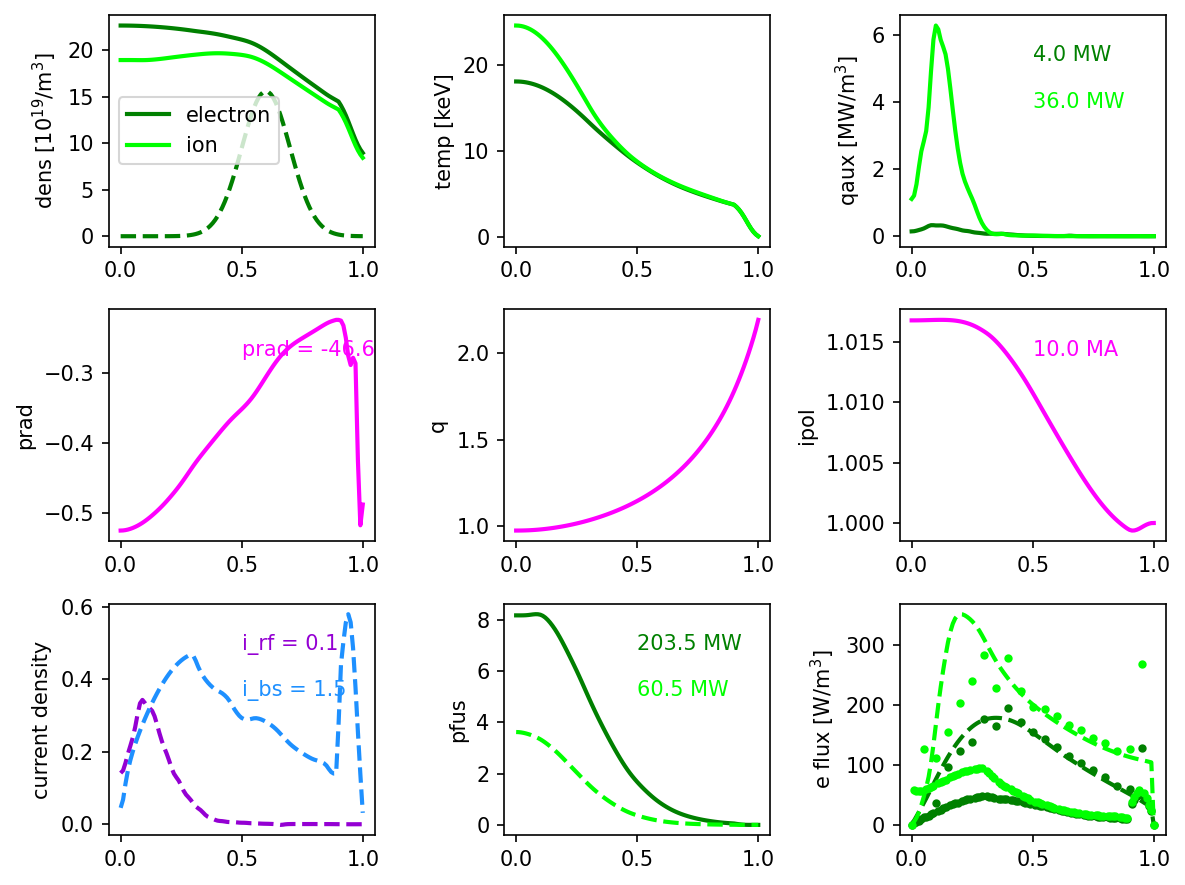

In [54]:
rho = rootgrp['rho'][:]

ne = rootgrp['ne'][-1,:]
nebar = rootgrp['nebar'][-1]
ni = rootgrp['ni'][-1,:] + rootgrp['nz0'][-1,:] + rootgrp['nz1'][-1,:] + rootgrp['nhe'][-1,:]

te = rootgrp['te'][-1,:]
teavg = rootgrp['tea'][-1]
ti = rootgrp['ti'][-1,:]
tiavg = rootgrp['tia'][-1]

sion = rootgrp['sion'][-1,:]

prfe = rootgrp['pe_rf'][-1,:]
prfe_int = rootgrp['prfe'][-1]
prfi = rootgrp['pi_rf'][-1,:]
prfi_int = rootgrp['prfi'][-1]

prad = rootgrp['p_rad'][-1,:]
prad_int = rootgrp['prad'][-1]

#betan = rootgrp['betan_loc'][-1,:]
#betan = p_vol_avg*1602.2*2*mu_0/Bt**2#*(aminor*Bt/Ip) ##FIXME doesn't make sense #approximate, check which B to use
betan_num = rootgrp['betan'][-1]

ipol = rootgrp['ipol'][-1,:]
ip = rootgrp['ip'][-1]

pfuse = rootgrp['pe_fus'][-1,:]
pfuse_int = rootgrp['pfuse'][-1]
pfusi = rootgrp['pi_fus'][-1,:]
pfusi_int = rootgrp['pfusi'][-1]

q = rootgrp['q'][-1,:]

jbs = rootgrp['j_bs'][-1,:]
ibs = rootgrp['ibs'][-1]
jrf = rootgrp['j_rf'][-1,:]
irf = rootgrp['irf'][-1]
jtot = rootgrp['j_tot'][-1,:]

fluxe = rootgrp['fluxe'][-1,:]
fluxe_exp = rootgrp['fluxe_exp'][-1,:]
fluxi = rootgrp['fluxi'][-1,:]
fluxi_exp = rootgrp['fluxi_exp'][-1,:]

fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) =plt.subplots(3,3,figsize =(8,6),dpi = 150)
lw = 2
c1 = 'green'
c2 = 'lime'
c3 = 'magenta'
c4 = 'darkviolet'
c5 = 'dodgerblue'
c6 = 'cyan'

ax1.plot(rho,ne,color = c1,linewidth = lw,label='electron')
ax1.plot(rho,ni,color = c2,linewidth = lw,label='ion')
ax1.plot(rho,sion,color = c1, linewidth = lw, linestyle = 'dashed')
ax2.plot(rho,te,color = c1,linewidth = lw)
ax2.plot(rho,ti,color = c2,linewidth = lw)
ax1.set_ylabel('dens [10$^{19}$/m$^3$]')
ax2.set_ylabel('temp [keV]')
ax1.legend()

ax3.plot(rho,prfe,color = c1,linewidth = lw)
ax3.plot(rho,prfi,color = c2,linewidth = lw)
#ax4.plot(rho,betan,color = c3,linewidth = lw)
ax3.set_ylabel('qaux [MW/m$^3$]')
ax3.text(0.5,0.8,'{:.1f} MW'.format(prfe_int),color = c1, transform = ax3.transAxes)
ax3.text(0.5,0.6,'{:.1f} MW'.format(prfi_int),color = c2, transform = ax3.transAxes)
ax4.set_ylabel('prad')
ax4.text(0.5,0.8,'prad = {:.1f}'.format(prad_int),color = c3, transform = ax4.transAxes)
ax4.plot(rho,prad,color = c3,linewidth=lw)

ax5.plot(rho,q,color = c3,linewidth = lw)
ax5.set_ylabel('q')

ax6.plot(rho,ipol,color = c3, linewidth = lw)
ax6.set_ylabel('ipol')
ax6.text(0.5,0.8,'{:.1f} MA'.format(ip),color = c3,transform = ax6.transAxes)

#ax7.plot(rho,jtot,color = c3,linewidth = lw)
ax7.plot(rho,jrf,color = c4,linewidth = lw,linestyle = 'dashed')
ax7.plot(rho,jbs,color = c5, linewidth =lw, linestyle='dashed')
ax7.text(0.5,0.8,'i_rf = {:.1f}'.format(irf),color = c4,transform = ax7.transAxes)
ax7.text(0.5,0.6,'i_bs = {:.1f}'.format(ibs),color = c5,transform = ax7.transAxes)
ax7.set_ylabel('current density')

ax8.plot(rho,5*pfuse,color = c1,linewidth = lw)
ax8.plot(rho,5*pfusi,color = c2,linewidth = lw,linestyle = 'dashed')
ax8.set_ylabel('pfus')
ax8.text(0.5,0.8,'{:.1f} MW'.format(5*pfuse_int),color = c1,transform = ax8.transAxes)
ax8.text(0.5,0.6,'{:.1f} MW'.format(5*pfusi_int),color = c2,transform = ax8.transAxes)

ax9.plot(rho,fluxe,'.',color =c1,linewidth = lw)
ax9.plot(rho,fluxe_exp,color = c1,linewidth = lw,linestyle = 'dashed')
ax9.plot(rho,fluxi,'.',color = c2,linewidth = lw)
ax9.plot(rho,fluxi_exp,color = c2,linewidth = lw,linestyle = 'dashed')
ax9.set_ylabel('e flux [W/m$^3$]')

fig.tight_layout()
plt.show()

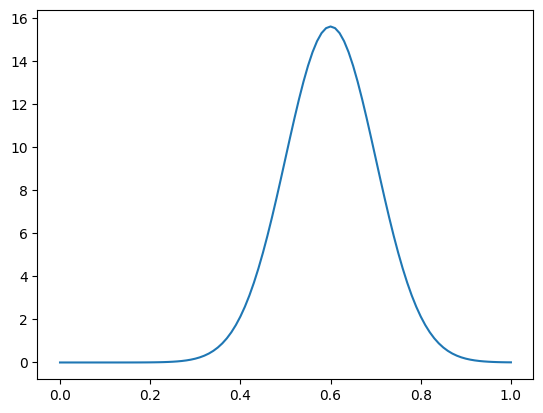

In [34]:
ptcl_src = rootgrp['sion'][-1,:]
plt.plot(rho,ptcl_src)

In [35]:
palpha = pfuse_int + pfusi_int
pin = prfe_int+prfi_int
psol = palpha+pin+prad_int
print(psol)
print(5*palpha/pin)

54.80740275236341
6.505073851048097


In [25]:
nKr = rootgrp['nz1'][-1,:]
nW = rootgrp['nz0'][-1,:]
nHe3 = rootgrp['nz2'][-1,:]
nHe4 = rootgrp['nhe'][-1,:]
print(nW/ne)

[1.5e-05 1.5e-05 1.5000000000000002e-05 1.5e-05 1.4999999999999999e-05
 1.5e-05 1.5e-05 1.5000000000000002e-05 1.5e-05 1.5e-05 1.5e-05
 1.5000000000000002e-05 1.4999999999999999e-05 1.4999999999999999e-05
 1.5000000000000002e-05 1.5e-05 1.5e-05 1.5e-05 1.4999999999999999e-05
 1.5e-05 1.5e-05 1.4999999999999999e-05 1.5e-05 1.5000000000000002e-05
 1.5000000000000002e-05 1.5e-05 1.5000000000000002e-05
 1.5000000000000002e-05 1.5e-05 1.5e-05 1.5e-05 1.5e-05
 1.4999999999999999e-05 1.5e-05 1.5e-05 1.4999999999999999e-05 1.5e-05
 1.4999999999999999e-05 1.5e-05 1.5e-05 1.5e-05 1.5e-05 1.5e-05 1.5e-05
 1.5e-05 1.5000000000000002e-05 1.5e-05 1.5e-05 1.5000000000000002e-05
 1.5e-05 1.5000000000000002e-05 1.5e-05 1.5000000000000002e-05 1.5e-05
 1.4999999999999999e-05 1.5000000000000002e-05 1.5e-05 1.5e-05
 1.5000000000000002e-05 1.5000000000000002e-05 1.5000000000000002e-05
 1.5000000000000002e-05 1.5e-05 1.5000000000000002e-05 1.5e-05
 1.4999999999999999e-05 1.5e-05 1.5e-05 1.5e-05 1.5e-05 1.5e-

5.0